In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

# Load datasets
buyer_profile = pd.read_csv('../data/processed/buyer_segmented_dataset.csv')
X = pd.read_csv('../data/processed/clustering_feature_matrix.csv')

print(buyer_profile.shape)
print(X.shape)

(855, 16)
(855, 13)


In [2]:
import os

folders = [
    '../reports/figures/eda',
    '../reports/figures/clustering',
    '../reports/figures/evaluation',
    '../reports/figures/business',
    '../reports/tables'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print('Output folders created successfully.')

Output folders created successfully.


In [3]:
fig = px.histogram(
    buyer_profile,
    x='age',
    nbins=20,
    title='Age Distribution of Buyers'
)

fig.update_layout(template='plotly_white')

# Display
fig.show()

# Save
fig.write_image(
    '../reports/figures/eda/age_distribution.png',
    scale=2
)

print('Age distribution saved.')

Age distribution saved.


In [4]:
segment_counts = (
    buyer_profile['buyer_segment']
    .value_counts()
    .reset_index()
)

segment_counts.columns = ['Buyer Segment', 'Buyers']

fig = px.bar(
    segment_counts,
    x='Buyer Segment',
    y='Buyers',
    color='Buyer Segment',
    title='Buyer Segment Distribution'
)

fig.show()

fig.write_image(
    '../reports/figures/clustering/segment_distribution.png',
    scale=2
)

print('Segment distribution saved.')

Segment distribution saved.


In [5]:
pca = PCA(n_components=2)
components = pca.fit_transform(X)

pca_df = pd.DataFrame({
    'PC1': components[:,0],
    'PC2': components[:,1],
    'Buyer Segment': buyer_profile['buyer_segment']
})

fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='Buyer Segment',
    title='PCA Visualization of Buyer Segments'
)

fig.show()

fig.write_image(
    '../reports/figures/clustering/pca_clusters.png',
    scale=2
)

print('PCA plot saved.')

PCA plot saved.


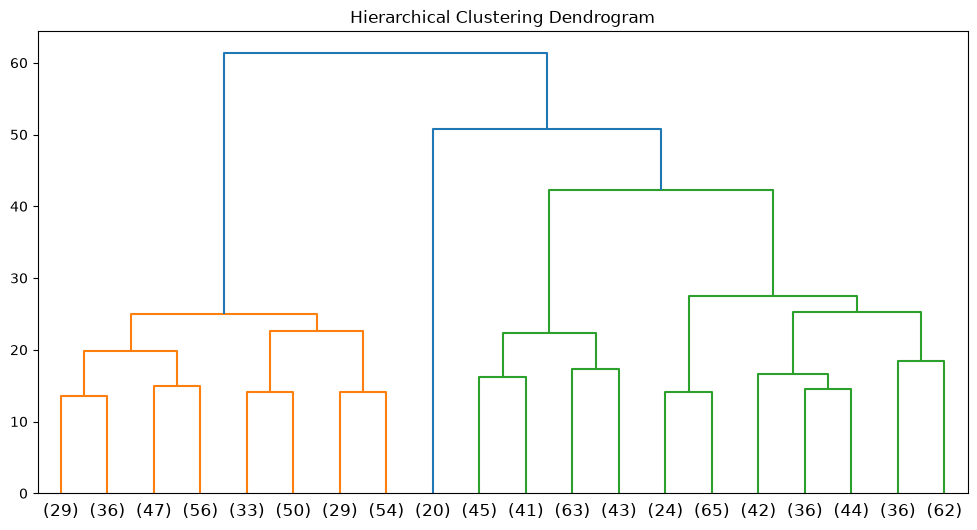

Dendrogram saved.


In [6]:
linkage_matrix = linkage(X, method='ward')

plt.figure(figsize=(12,6))

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=20
)

plt.title('Hierarchical Clustering Dendrogram')

# Save
plt.savefig(
    '../reports/figures/clustering/dendrogram.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('Dendrogram saved.')

In [7]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

clusters = buyer_profile['cluster']

evaluation = pd.DataFrame({
    'Metric': [
        'Silhouette Score',
        'Davies-Bouldin Index',
        'Calinski-Harabasz Score'
    ],
    'Value': [
        silhouette_score(X, clusters),
        davies_bouldin_score(X, clusters),
        calinski_harabasz_score(X, clusters)
    ]
})

evaluation.to_csv(
    '../reports/tables/evaluation_metrics.csv',
    index=False
)

evaluation

,Metric,Value
0,Silhouette Score,0.224781
1,Davies-Bouldin Index,1.363704
2,Calinski-Harabasz Score,238.371089


In [8]:
fig = px.histogram(
    buyer_profile,
    x='total_investment_value',
    nbins=30,
    title='Distribution of Total Investment Value'
)

fig.update_layout(template='plotly_white')

fig.show()

fig.write_image(
    '../reports/figures/eda/investment_value_distribution.png',
    scale=3,
    width=1200,
    height=700
)

print('Saved: reports/figures/eda/investment_value_distribution.png')

Saved: reports/figures/eda/investment_value_distribution.png


In [9]:
corr = buyer_profile[
    [
        'age',
        'satisfaction_score',
        'total_properties_owned',
        'total_investment_value',
        'average_property_value',
        'average_floor_area'
    ]
].corr()

fig = px.imshow(
    corr,
    text_auto='.2f',
    color_continuous_scale='Blues',
    title='Correlation Matrix of Buyer Features'
)

fig.update_layout(template='plotly_white')

fig.show()

fig.write_image(
    '../reports/figures/eda/correlation_matrix.png',
    scale=3,
    width=1000,
    height=900
)

print('Saved: reports/figures/eda/correlation_matrix.png')

Saved: reports/figures/eda/correlation_matrix.png


In [10]:
inertia = []

k_values = range(2, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X)
    inertia.append(model.inertia_)

elbow_df = pd.DataFrame({
    'K': list(k_values),
    'Inertia': inertia
})

fig = px.line(
    elbow_df,
    x='K',
    y='Inertia',
    markers=True,
    title='Elbow Method for Optimal Number of Clusters'
)

fig.update_layout(template='plotly_white')

fig.show()

fig.write_image(
    '../reports/figures/clustering/elbow_method.png',
    scale=3,
    width=1200,
    height=700
)

print('Saved: reports/figures/clustering/elbow_method.png')

Saved: reports/figures/clustering/elbow_method.png


In [11]:
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

silhouette_df = pd.DataFrame({
    'K': list(k_values),
    'Silhouette Score': silhouette_scores
})

fig = px.line(
    silhouette_df,
    x='K',
    y='Silhouette Score',
    markers=True,
    title='Silhouette Score by Number of Clusters'
)

fig.update_layout(template='plotly_white')

fig.show()

fig.write_image(
    '../reports/figures/clustering/silhouette_analysis.png',
    scale=3,
    width=1200,
    height=700
)

print('Saved: reports/figures/clustering/silhouette_analysis.png')

Saved: reports/figures/clustering/silhouette_analysis.png


In [12]:
regional_summary = (
    buyer_profile
    .groupby('region')
    .agg(
        Buyers=('client_id', 'count'),
        Average_Investment=('total_investment_value', 'mean')
    )
    .reset_index()
)

fig = px.bar(
    regional_summary,
    x='region',
    y='Average_Investment',
    color='Average_Investment',
    text='Average_Investment',
    title='Average Investment Value by Region'
)

fig.update_layout(template='plotly_white')

fig.show()

fig.write_image(
    '../reports/figures/business/regional_investment_analysis.png',
    scale=3,
    width=1200,
    height=700
)

regional_summary.to_csv(
    '../reports/tables/regional_summary.csv',
    index=False
)

print('Saved: reports/figures/business/regional_investment_analysis.png')
print('Saved: reports/tables/regional_summary.csv')

Saved: reports/figures/business/regional_investment_analysis.png
Saved: reports/tables/regional_summary.csv
